#Email Spam Detection using Machine Learning

# Problem Statement:
The objective of this project is to classify emails as spam or not spam using machine learning techniques. 
This helps in filtering unwanted emails and improving user experience.

# Data Description:
The dataset contains email messages along with their labels (spam or not spam).
This data is used to train the model.

In [1]:
#Importing required libraries for data processing and model building
import pandas as pd
import numpy as np

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression

In [2]:
# Loading dataset
df = pd.read_csv("phishing_email.csv")

df.head()

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [3]:
# Data Understanding
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82486 entries, 0 to 82485
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text_combined  82486 non-null  object
 1   label          82486 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.3+ MB


In [4]:
df['label'].value_counts()

label
1    42891
0    39595
Name: count, dtype: int64

In [5]:
#remove unwamted one
df = df[['text_combined', 'label']]

In [6]:
df = df[df['text_combined'].str.strip() != ""]


In [18]:
#Function to clean text data
def clean_text(text):
    text = text.lower()  # convert to lowercase
    text = re.sub(r'\d+', '', text)  # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = text.strip()
    return text

In [19]:
print(df.columns)

Index(['text_combined', 'label', 'cleaned_text'], dtype='object')


In [20]:
#Cleaning
df['cleaned_text'] = df['text_combined'].apply(clean_text)

In [21]:
#spliting data here
X = df['cleaned_text']
y = df['label']

In [22]:
#train-test-split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)     

In [23]:
#TF-IDF(Term Frequency – Inverse Document Frequency)
# Converting text into numerical form using TF-IDF
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [27]:
#Train the model
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [28]:
y_pred_nb = nb_model.predict(X_test_tfidf)

In [29]:
# Logistic Regression
# Training Logistic Regression model
log_reg = LogisticRegression()
log_reg.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [34]:
y_pred_lr = log_reg.predict(X_test_tfidf)

In [35]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nNaive Bayes Report:\n", classification_report(y_test, y_pred_nb))
print("\nLogistic Regression Report:\n", classification_report(y_test, y_pred_lr))

Naive Bayes Accuracy: 0.9591440868036613
Logistic Regression Accuracy: 0.981390555858641

Naive Bayes Report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96      7919
           1       0.98      0.94      0.96      8578

    accuracy                           0.96     16497
   macro avg       0.96      0.96      0.96     16497
weighted avg       0.96      0.96      0.96     16497


Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      7919
           1       0.98      0.98      0.98      8578

    accuracy                           0.98     16497
   macro avg       0.98      0.98      0.98     16497
weighted avg       0.98      0.98      0.98     16497



In [36]:
print(confusion_matrix(y_test, y_pred_nb))  #confusion matrix

[[7737  182]
 [ 492 8086]]


In [37]:
#Predicting the spam
def predict_email(email_text):
    cleaned = clean_text(email_text)
    vectorized = tfidf.transform([cleaned])
    prediction = model.predict(vectorized)
    return "Spam" if prediction[0] == 1 else "Not Spam"


In [38]:
#testing the model
print(predict_email("Congratulations! You won a free iPhone. Click now!"))


Spam


In [39]:
print(predict_email("Meeting is scheduled at 10 AM"))

Not Spam


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

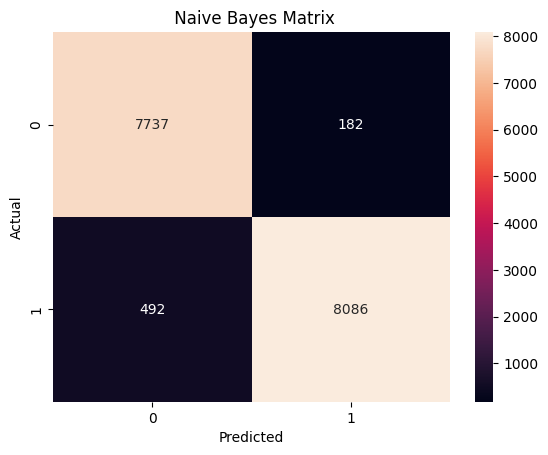

In [41]:
#Visualization
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm, annot=True, fmt='d')
plt.title(" Naive Bayes Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

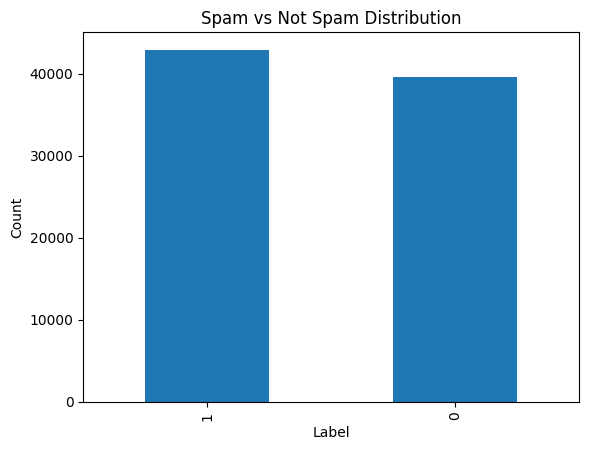

In [42]:
df['label'].value_counts().plot(kind='bar')
plt.title("Spam vs Not Spam Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

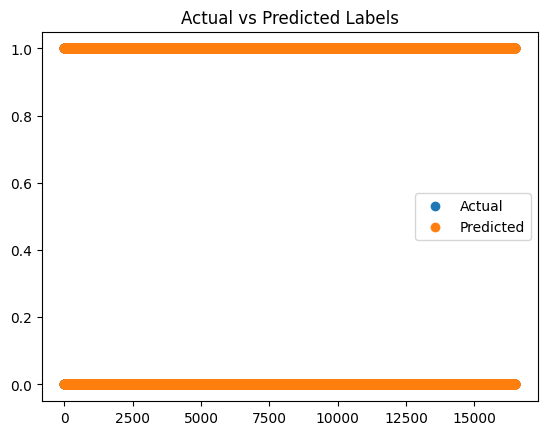

In [43]:
plt.scatter(range(len(y_test)), y_test, label='Actual')
plt.scatter(range(len(y_pred_nb)), y_pred_nb, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Labels")
plt.show()

#Conclusion
In this project, I worked on building a system to detect whether an email is spam or not using machine learning.
First, I cleaned the text data and converted it into numerical form using TF-IDF, so that the model can understand it. Then I applied two models, Naive Bayes and Logistic Regression, to classify the emails.
After testing both models, I observed that both performed well, but Logistic Regression gave slightly better accuracy compared to Naive Bayes.
This project shows how machine learning can be used in real-life applications like email filtering to automatically identify spam messages.

In [1]:
import os
print(os.getcwd())

C:\Users\deore
